# AMAZON SALES DATASET


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("amazon.csv")

In [3]:
df.head(3)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


In [4]:
#Verificando se há valores nulos
df.isnull().sum()
#Removendo os dois nulos encontrados
df  = df.dropna()

In [5]:
#Limpando a base de dados

# Limpeza na coluna actual_price
df['actual_price'] = (
    df['actual_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.extract(r'^(\d{2,4})')[0]
    .astype(float)
)


#Limpeza na coluna discount_percentage
df['discount_percentage'] = (
    df['discount_percentage']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

# Gráfico da Média de Preço por Categoria

In [6]:
#Abaixo, atualizei a coluna category, pegando apenas o que vem antes da primeira '|'
df['category'] = df['category'].str.split('|').str[0]

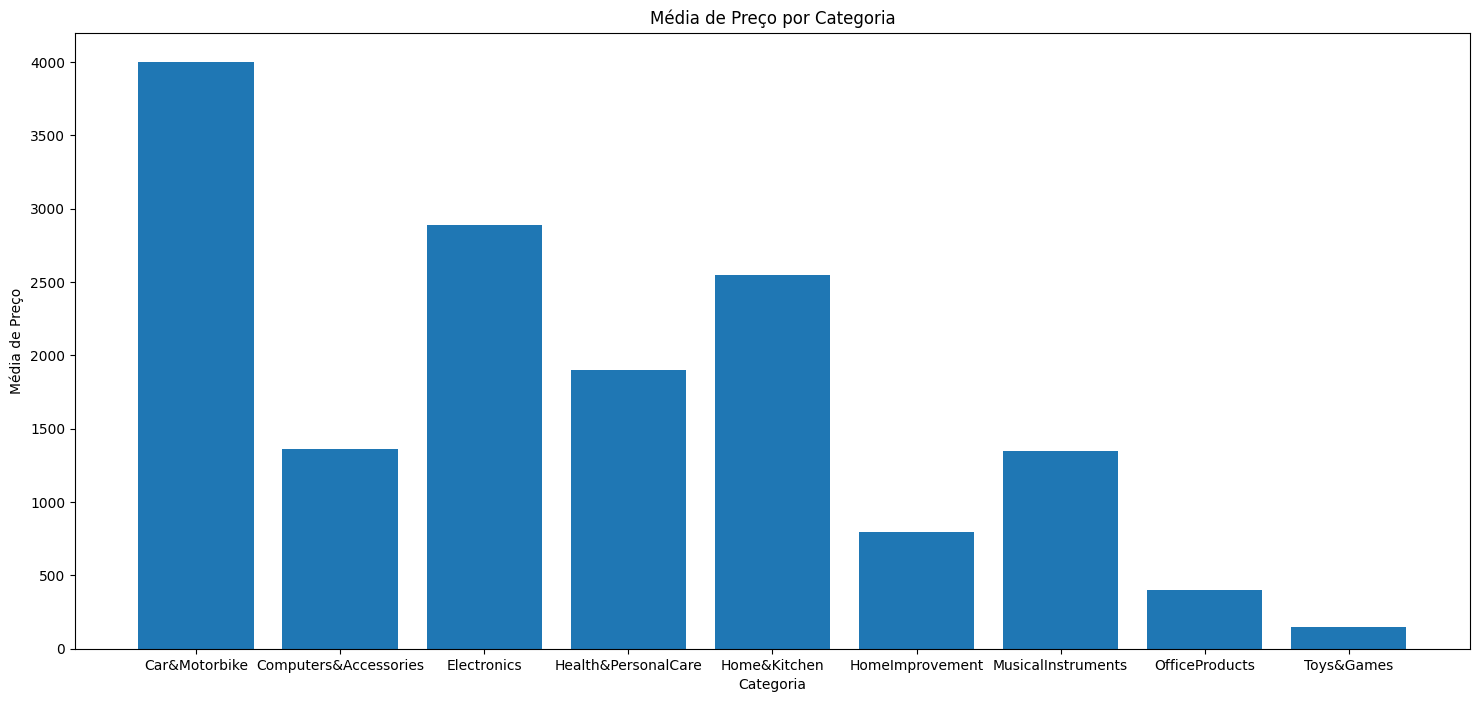

In [7]:
media_por_categoria = df.groupby('category')['actual_price'].mean()

plt.figure(figsize=(18,8))
plt.bar(media_por_categoria.index, media_por_categoria.values)
plt.xlabel('Categoria')
plt.ylabel('Média de Preço')
plt.title('Média de Preço por Categoria')
plt.show()

Com base no gráfico acima, onde foi exibida a média de preço por categoria geral, é possível concluir que, nas vendas da Amazon, as top 5 categorias gerais com maior média de preço são: Car & Motorbike; Eletronics;Home & Kitchen; Health & PersonalCare; Computer & Accessories

# Relação entre Avaliação e Preço


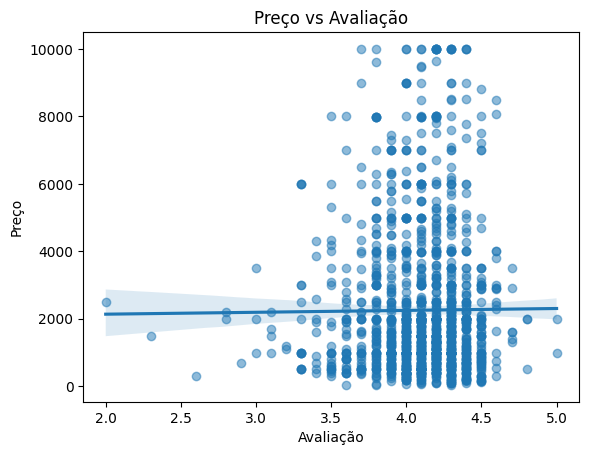

Com base no índice de correlação de Pearson que se aproxima de 0.0076 a correlação é extremamente fraca.


In [8]:
nota_preco_associados = df.groupby('rating')['actual_price'].mean()


#Limpeza na coluna rating (ela estava sendo tratada como string)
df['rating'] = pd.to_numeric(df['rating'].astype(str).str.strip(), errors='coerce')

#Gráfico
sns.regplot(
    data=df,
    x='rating',
    y='actual_price',
    scatter_kws={'alpha':0.5}
)
plt.xlabel('Avaliação')
plt.ylabel('Preço')
plt.title('Preço vs Avaliação')
plt.show()

print(f"Com base no índice de correlação de Pearson que se aproxima de {df['rating'].corr(df['actual_price']):.4f} a correlação é extremamente fraca.")

A relação entre preço e avaliação nos permite concluir algumas coisas:

Produtos caros (6k a 10k): Concentram-se, em sua maioria, acima da nota 4.0, com raros outliers entre 3.0 e 3.5.

Produtos baratos (até 2.5k): Concentram quase todas as notas abaixo de 3.0, mas também formam a maior densidade de avaliações positivas (3.8 a 4.5). Logo, preço baixo não dita nota baixa.

Faixa de 3.0 a 3.5: é como se fosse tipo uma zona de transição onde produtos de médio e alto valor começam a aparecer.

Conclusão: O índice de Pearson de 0.0076 confirma visualmente o que a estatística prova: a correlação linear entre preço e avaliação é praticamente nula.

# Relação entre Desconto e Avaliação
Será que produtos com grande porcentagem de desconto têm avaliações maiores?

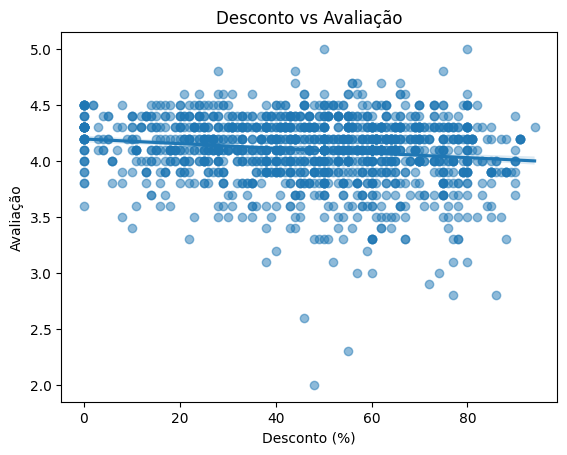

Índice de correlação de Pearson ~= -0.1557 


In [9]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

sns.regplot(
    data=df,
    x='discount_percentage',
    y='rating',
    scatter_kws={'alpha':0.5}
)
plt.xlabel('Desconto (%)')
plt.ylabel('Avaliação')
plt.title('Desconto vs Avaliação')
plt.show()

print(f"Índice de correlação de Pearson ~= {df['discount_percentage'].corr(df['rating']):.4f} ")

Com base no índice de correlação de Pearson que se aproxima de -0.1557 a correlação é forte negativa. Logo, os produtos com maior desconto não têm, obrigatoriamente, avaliações maiores. Da mesma forma que, no gráfico vemos produtos com descontos pequenos e até inexistentes que mesmo assim têm avaliações altas.

# Top categorias com maior quantidade de produtos

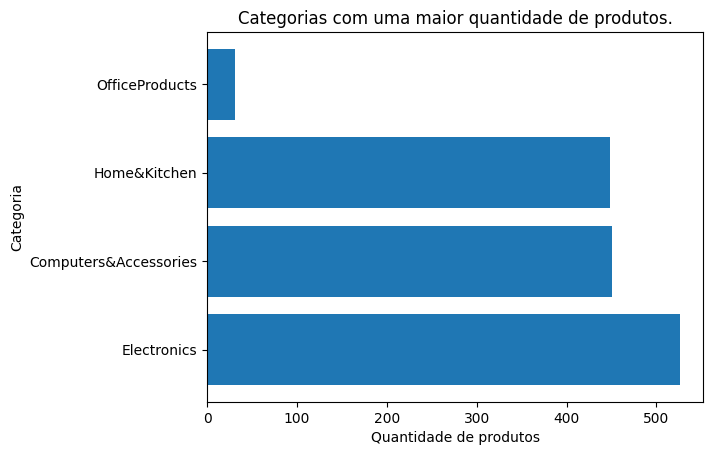

In [10]:
top_categorias_produtos = df.groupby('category')['product_name'].count()
top_categorias_produtos = top_categorias_produtos[top_categorias_produtos >= 10].sort_values(ascending=False)

#criando o gráfico
plt.barh(top_categorias_produtos.index, top_categorias_produtos.values)
plt.title("Categorias com uma maior quantidade de produtos.")
plt.xlabel("Quantidade de produtos")
plt.ylabel("Categoria")

plt.show()

Com base nessa visualização, é notório que a categoria de eletrônicos é a que contém maior quantidade de produtos cadastrados.
Essa comparação foi fundamental para ilustrar os perigos de analisar médias isoladamente. No gráfico (Média de Preço por Categoria), a categoria Car & Motorbike apresentava o maior valor médio. No entanto, a análise de volume revela que essa média foi distorcida, pois baseou-se em um único produto cadastrado. Isso demonstra que a categoria não tem relevância em volume, apesar do alto valor desse item.

# Top categorias com maior valor total acumulado

In [11]:
faturamento_por_categoria = df.groupby('category')['actual_price'].sum().head(5)
faturamento_por_categoria = faturamento_por_categoria.sort_values(ascending=False)

#Transformando em dataframe
df_faturamento = faturamento_por_categoria.reset_index()
df_faturamento.columns = ['Categoria', 'Faturamento_Total']

print(df_faturamento)

               Categoria  Faturamento_Total
0            Electronics          1518926.0
1           Home&Kitchen          1141492.0
2  Computers&Accessories           614206.0
3          Car&Motorbike             4000.0
4    Health&PersonalCare             1900.0


Como era de se esperar, com base nas visualizações anteriores, a categoria de eletrônicos teve o maior faturamento total (em Rúpias Indianas ₹). E, para sintetizar e comprovar as análises anteriores, a categoria de Car & Motorbike realmente só teve um único produto e ele custava 4000 rúpias, por isso a sua média ficou tão alta.